# Module #14 - Binding site detection
Authors:

* Adapted from Abishek Laxmanan Ravi Shankar, 2019, internship at Volkamer lab
* Andrea Volkamer, 2020/21, [Volkamer lab, Charité](https://volkamerlab.org/)
* Dominique Sydow, 2020/21, [Volkamer lab, Charité](https://volkamerlab.org/)

## Aim of this Module

The binding site of a protein is the key to its function. In this Module, we introduce the concepts of computational binding site detection tools using DoGSiteScorer from the [protein.plus](https://proteins.plus/) web server, exemplified on an PAK1 structure. 
Additionally, we compare the results to the pre-defined KLIFS binding site by calculating the percentage of residues in accordance between the two sets.

### References
* Prediction, Analysis, and Comparison of Active Sites [Volkamer <i>et al.</i>, (<b>2018</b>)](https://doi.org/10.1002/9783527806539.ch6g), book chapter in Applied Chemoinformatics: Achievements and Future Opportunities, Wiley
* DoGSiteScorer, [Volkamer <i>et al.</i>, <i>J.Chem.Inf.Model</i>, (<b>2012</b>), 52(2):360-372](https://pubmed.ncbi.nlm.nih.gov/22148551/)
* [ProteinsPlus](https://proteins.plus/): a web portal for structure analysis of macromolecules. [Fährrolfes <i>et al.</i>, <i>NAR</i>, (<b>2017</b>), 3;45(W1)](https://pubmed.ncbi.nlm.nih.gov/28472372/)
* [KLIFS](https://klifs.net/): a structural kinase-ligand interaction database, [Kanev <i>et al.</i>, <i>NAR</i>, (<b>2021</b>), 49(D1):D562-D569](https://academic.oup.com/nar/article/49/D1/D562/5934416) 

## Practical

In this practical part, we will introduce how to query the [proteins.plus](https://proteins.plus) server for binding site detection using DoGSiteScorer for our protein of interest.

Import all necessary libraries.

In [1]:
import io
from pathlib import Path
import time
import gzip

import requests
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import pandas as pd
from biopandas.pdb import PandasPdb
import nglview

from opencadd.databases.klifs import setup_remote

pd.set_option("display.max_columns", 50)

Add globals to this talktorial's path (`HERE`) and its data folder (`DATA`).

In [2]:
HERE = Path(_dh[-1])
DATA = HERE / "data"
DATATMP = DATA / "_tmp"
DATATMP.mkdir(parents=True, exist_ok=True)

### Binding site detection using DoGSiteScorer
We first define a function to query the server for a protein of interest.
Infos on the REST API can be found [here](https://proteins.plus/help/dogsite_rest).

In [3]:
def submit_dogsitescorer_job_with_pdbid(pdb_code, chain_id, ligand=""):
    """
    Submit PDB ID to DoGSiteScorer webserver using their API and get back URL for job location.

    Parameters
    ----------
    pdb_code : str
        4-letter valid PDB ID, e.g. '3w32'.
    chain_id : str
        Chain ID, e.g. 'A'.
    ligand : str
        Name of ligand bound to PDB structure with pdb_id, e.g. 'W32_A_1101'.
        Currently, the ligand name must be checked manually on the DoGSiteScorer website.

    Returns
    -------
    str
        Job location URL for submitted query.

    References
    ----------
    Function is adapted from: https://github.com/volkamerlab/TeachOpenCADD/pull/3 (@jaimergp)
    """

    # Submit job to proteins.plus
    # For details on parameters see: https://proteins.plus/help/dogsite_rest
    r = requests.post(
        "https://proteins.plus/api/dogsite_rest",
        json={
            "dogsite": {
                "pdbCode": pdb_code,  # PDB code of protein
                "analysisDetail": "1",  # 1 = include subpockets in results
                "bindingSitePredictionGranularity": "1",  # 1 = include drugablity scores
                "ligand": ligand,  # if name is specified, ligand coverage is calculated
                "chain": chain_id,  # if chain is specified, calculation is only performed on this chain
            }
        },
        headers={"Content-type": "application/json", "Accept": "application/json"},
    )

    r.raise_for_status()

    return r.json()["location"]

#### Job submission for structure of interest

Define the protein of interest. As an example, we chose an PAK1 kinase structure, more details can be found in the respective PDB entry: [4EQC](https://www.rcsb.org/structure/4EQC).

In [4]:
pdb_id = "4EQC"
chain_id = "A"
# Ligand id manually looked-up from DoGSiteScorer within proteins.plus
# Note that it is generally composed of [pdb_lig_id]_[chain_id]_[pdb_residue_id]
ligand_id = "XR1_A_601"

Submit the query and identify the job location (URL) on the web server for further investigation.

In [5]:
job_location = submit_dogsitescorer_job_with_pdbid(pdb_id, chain_id, ligand_id)
job_location

'https://proteins.plus/api/dogsite_rest/sBxm85NV67b9GdyhMX3hohmy'

#### Get DoGSiteScorer pocket metadata
We now define a function that collects all data returned by the server and stores them in a pandas `DataFrame`.

In [6]:
def get_dogsitescorer_metadata(job_location, attempts=30):
    """
    Get results from a DoGSiteScorer query, i.e., the binding sites which are found over the protein surface,
    in the form of a table with the details about all detected pockets.

    Parameters
    ----------
    job_location : str
        Consists of the location of a finished DoGSiteScorer job on the proteins.plus web server.
    attempts : int
        The time waiting for the feedback from DoGSiteScorer service.

    Returns
    -------
    pandas.DataFrame
        Table with metadata on detected binding sites.
    """

    print(f"Querying for job at URL {job_location}...", end="")

    while attempts:
        # Get job results
        result = requests.get(job_location)
        result.raise_for_status()
        # Get URL of result table file
        response = result.json()
        if "result_table" in response:
            result_file = response["result_table"]
            break
        attempts -= 1
        print(".", end="")
        time.sleep(10)
    # Get result table (as string)
    result_table = requests.get(result_file).text
    # Load the table (csv format using "\t" as separator) with pandas DataFrame
    # We cannot load the table from a string directly but from a file
    # Use io.StringIO to wrap this string as file-like object as needed for read_csv method
    # See more: https://docs.python.org/3/library/io.html#io.StringIO
    result_table_df = pd.read_csv(io.StringIO(result_table), sep="\t").set_index("name")

    return result_table_df

All detected pockets from DoGSiteScorer web server are retrieved and a dataframe is returned containing all pocket descriptor information.

In [7]:
metadata = get_dogsitescorer_metadata(job_location)
metadata.head()

Querying for job at URL https://proteins.plus/api/dogsite_rest/sBxm85NV67b9GdyhMX3hohmy...

,lig_cov,poc_cov,lig_name,volume,enclosure,surface,depth,surf/vol,lid/hull,ellVol,ell c/a,ell b/a,siteAtms,accept,donor,hydrophobic_interactions,hydrophobicity,metal,Cs,Ns,Os,Ss,Xs,negAA,posAA,polarAA,apolarAA,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL,simpleScore,drugScore
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
P_0,71.64,43.63,XR1_A_601,875.52,0.12,964.26,18.13,1.101357,-,-,0.13,0.24,164,35,17,58,0.53,0,119,21,21,3,0,0.11,0.09,0.23,0.57,2,1,0,2,0,1,2,2,0,4,4,2,3,2,1,2,1,0,2,4,0.62,0.821412
P_0_0,71.64,49.19,XR1_A_601,776.64,0.10,932.45,18.13,1.200621,-,-,0.09,0.21,155,31,16,55,0.54,0,113,20,19,3,0,0.09,0.09,0.24,0.59,2,1,0,1,0,1,2,2,0,4,4,2,3,2,1,2,1,0,2,4,0.75,0.795249
P_0_1,0.00,0.00,XR1_A_601,98.88,0.25,296.58,6.50,2.999393,-,-,0.29,0.44,29,10,7,19,0.53,0,19,5,5,0,0,0.38,0.12,0.25,0.25,0,1,0,2,0,0,1,1,0,0,0,0,0,2,0,1,0,0,0,0,0.00,0.092989
P_1,0.00,0.00,XR1_A_601,297.47,0.18,572.17,14.57,1.923454,-,-,0.14,0.42,91,32,5,22,0.37,0,62,11,16,2,0,0.20,0.05,0.25,0.50,0,0,1,1,1,1,3,1,0,2,2,1,2,1,1,0,1,0,0,2,0.13,0.623476
P_1_0,0.00,0.00,XR1_A_601,110.02,0.17,283.60,9.67,2.577713,-,-,0.21,0.57,39,12,1,11,0.46,0,30,3,6,0,0,0.12,0.12,0.25,0.50,0,0,1,0,0,1,1,0,0,1,2,1,0,0,1,0,0,0,0,0,0.02,0.304499


**Note**: We selected to have pockets and subpockets returned from the algorithm, e.g. pocket ``P_0`` contains subpockets ``P_0_0`` to ``P_0_5``. Depending on your research question you might prefer to work with the pockets - mostly if you are more interested in the general location (e.g. for docking) - or the subpockets, which give a more granular description.

#### Pick the most suitable pocket
The pockets are initially sorted by the volume of the respective pocket.
We want to have a deeper look at the pocket that contains the ligand (see ligand coverage column ``lig_cov``) and which is covered by the ligand the most (pocket coverage ``poc_cov``). 

For clarity, we drop a few columns first from the dataframe.

In [8]:
metadata = metadata[
    [
        "lig_cov",
        "poc_cov",
        "lig_name",
        "volume",
        "enclosure",
        "surface",
        "depth",
        "surf/vol",
        "accept",
        "donor",
        "hydrophobic_interactions",
        "hydrophobicity",
        "metal",
        "simpleScore",
        "drugScore",
    ]
]

Sort the obtained binding site by your column of interest.

In [9]:
metadata.sort_values(by=["lig_cov", "poc_cov"], ascending=False).head()
# NBVAL_CHECK_OUTPUT

,lig_cov,poc_cov,lig_name,volume,enclosure,surface,depth,surf/vol,accept,donor,hydrophobic_interactions,hydrophobicity,metal,simpleScore,drugScore
name,,,,,,,,,,,,,,,
P_0_0,71.64,49.19,XR1_A_601,776.64,0.10,932.45,18.13,1.200621,31,16,55,0.54,0,0.75,0.795249
P_0,71.64,43.63,XR1_A_601,875.52,0.12,964.26,18.13,1.101357,35,17,58,0.53,0,0.62,0.821412
P_0_1,0.00,0.00,XR1_A_601,98.88,0.25,296.58,6.50,2.999393,10,7,19,0.53,0,0.00,0.092989
P_1,0.00,0.00,XR1_A_601,297.47,0.18,572.17,14.57,1.923454,32,5,22,0.37,0,0.13,0.623476
P_1_0,0.00,0.00,XR1_A_601,110.02,0.17,283.60,9.67,2.577713,12,1,11,0.46,0,0.02,0.304499


**Note**: We decided here to select the pocket with the best ligand and pocket coverage to have a precise description of the pocket for our comparison later. In other drug design scenarios, you might want to simply sort by ``drugScore`` (``metadata.sort_values(by='drugScore', ascending=False)``) or other values, such as ``volume`` or ``simpleScore``.

We define a function that returns the ID (variable is called ``best_pocket_id``) of the pocket that fullfills our sorting criterion.

In [10]:
def select_best_pocket(metadata, sorted_by="drugScore"):
    """
    This function uses the defined sorting parameter to identify
    the best pocket among the obtained pockets.

    Parameters
    ----------
    metadata : pd.DataFrame
        Pockets retrieved from the DoGSiteScorer website

    by : str
        Method name(s) to sort table by (default is to sort by drugScore).

    Returns
    -------
    str
        Best binding site name.
    """

    by_methods = ["drugScore", "volume", "simpleScore", "lig_cov", "poc_cov"]

    # Sort by the selected method
    if all(elem in by_methods for elem in sorted_by):
        sorted_pocket = metadata.sort_values(sorted_by, ascending=False)
    else:
        raise ValueError(f'Selection method not in list: {", ".join(by_methods)}')

    # Get name of best pocket
    best_pocket_name = sorted_pocket.iloc[0, :].name

    return best_pocket_name

We now programatically access the name of the best pocket based on the selected sorting.

In [11]:
best_pocket_id = select_best_pocket(metadata, ["lig_cov", "poc_cov"])
best_pocket_id
# NBVAL_CHECK_OUTPUT

'P_0_0'

#### Get binding site file content

We define two helper functions to first get the URL for all pocket pdb or ccp4 files, respectively. Then, we only process the files further for our pocket of interest.

Note that DoGSiteScorer returns two structural (3D) file formats per pocket:

* *pdb*: These files contain all atoms/residues surrounding the pocket.
    * Accessed via ``residues``
    * Naming scheme, e.g. 4ecq_P_0_0``_res.pdb``
* *ccp4*: These files contain the grid points composing the pocket, also considered the *volume* of the pocket.
    * Accessed via ``pockets``
    * Naming scheme, e.g. 4ecq_P_0_0``_gpsAll.ccp4.gz``

In [12]:
def get_url_for_pockets(job_location, file_type="pdb"):
    """
    Get all pocket file locations for a finished DoGSiteScorer job
    for a selected file type (pdb/ccp4).

    Parameters
    ----------
    job_location : str
        URL of finished job submitted to the DoGSiteScorer web server.
    file_type : str
        Type of file to be returned (pdb/ccp4).

    Returns
    -------
    list
        List of all respective pocket file URLs.
    """

    # Get job results
    result = requests.get(job_location)

    if file_type == "pdb":
        # Get pocket residues
        return result.json()["residues"]
    elif file_type == "ccp4":
        # Get pocket volumes
        return result.json()["pockets"]
    else:
        raise ValueError(f"File type {file_type} not available.")

In [13]:
def get_selected_pocket_location(job_location, best_pocket, file_type="pdb"):
    """
    Get the selected binding site file location.

    Parameters
    ----------
    job_location : str
        URL of finished job submitted to the DoGSiteScorer web server.
    best_pocket : str
        Selected pocket id.
    file_type : str
        Type of file to be returned (pdb/ccp4).

    Returns
    ------
    str
        URL of selected pocket file on the DoGSiteScorer web server.
    """
    result = []

    # Get URL for all available pdb or ccp4 files
    pocket_files = get_url_for_pockets(job_location, file_type)

    for pocket_file in pocket_files:
        if file_type == "pdb":
            if f"{best_pocket}_res" in pocket_file:
                result.append(pocket_file)
        elif file_type == "ccp4":
            if f"{best_pocket}_gpsAll" in pocket_file:
                result.append(pocket_file)

    if len(result) > 1:
        raise TypeError(f'Multiple strings detected: {", ".join(result)}.')
    elif len(result) == 0:
        raise TypeError(f"No string detected.")
    else:
        pass

    return result[0]

Get URL for PDB file containing the selected pocket's residues.

In [14]:
selected_pocket_residues_url = get_selected_pocket_location(job_location, best_pocket_id, "pdb")
selected_pocket_residues_url

'https://proteins.plus/results/dogsite/sBxm85NV67b9GdyhMX3hohmy/4eqc_P_0_0_res.pdb'

#### Investigate detected pocket

**Pocket descriptors**

The algorithm returns information on all calculated descriptors for the respective pocket. 

In [15]:
metadata.loc[best_pocket_id]
# NBVAL_CHECK_OUTPUT

lig_cov                         71.64
poc_cov                         49.19
lig_name                    XR1_A_601
volume                         776.64
enclosure                         0.1
surface                        932.45
depth                           18.13
surf/vol                     1.200621
accept                             31
donor                              16
hydrophobic_interactions           55
hydrophobicity                   0.54
metal                               0
simpleScore                      0.75
drugScore                    0.795249
Name: P_0_0, dtype: object

**Visualize the pocket**

We need to get the respective ``ccp4`` file that contains the pocket information. First, we get the URL for the``ccp4`` file containing the selected pocket's volume.

In [16]:
selected_pocket_volume_url = get_selected_pocket_location(job_location, best_pocket_id, "ccp4")
selected_pocket_volume_url

'https://proteins.plus/results/dogsite/sBxm85NV67b9GdyhMX3hohmy/4eqc_P_0_0_gpsAll.ccp4.gz'

We get the grid point coordinates from that proteins.plus URL. We do not save this to disk, but to a memory file (`io.BytesIO`). Thanks to the extension in the URL, we know this is a gzipped (`.gz` extension) CCP4 map (`.ccp4`). What we do:

1. Download the file from the server into memory. At this point we have gzipped bytes.
2. We decompress the response in memory using `gzip.decompress`.
3. We wrap it in a `io.BytesIO` object that will behave as an opened file.

In [17]:
r = requests.get(selected_pocket_volume_url)
r.raise_for_status()
# Decompress response content and wrap it in a file-like object
memfile = io.BytesIO(gzip.decompress(r.content))

**Note**: If the pocket volume does not show in the NGLviewer, please try to run the notebook with Jupyter Notebook (instead of Jupyter Lab).

In [18]:
viewer = nglview.show_pdbid(pdb_id)
# Since we are passing bytes with no path or extension
# we need to tell nglview what kind of data this is: ccp4
viewer.add_component(memfile, ext="ccp4")
viewer.center()
viewer

NGLWidget()

In [19]:
viewer.render_image(trim=True, factor=2);

In [20]:
viewer._display_image()

The above rendered image shows the same content as when using the proteins.plus web server directly (see Figure 1). 

### Comparison between DoGSiteScorer and KLIFS pocket

#### Get DoGSiteScorer pocket residues
Since we want to compare the automatically predicted pocket with the manually assigned KLIFS pocket, we need to identify the pocket residues.

In [21]:
def get_pocket_residues(pocket_url):
    """
    Gets residue IDs and names of a specified pocket (via URL).

    Parameters
    ----------
    pocket_url : str
        URL of selected pocket file on the DoGSiteScorer web server.

    Returns
    -------
    pandas.DataFrame
        Table of residues names and IDs for the selected binding site.
    """

    # Retrieve PDB file content from URL
    result = requests.get(pocket_url)

    # Get content of PDB file
    pdb_residues = result.text

    # Load PDB format as DataFrame
    ppdb = PandasPdb().read_pdb_from_list(pdb_residues.splitlines(True))
    pdb_df = ppdb.df["ATOM"]

    # Drop duplicates
    # PDB file contains per atom entries, we only need per residue info
    pdb_df.sort_values("residue_number", inplace=True)
    pdb_df.drop_duplicates(subset="residue_number", keep="first", inplace=True)

    return pdb_df[["residue_number", "residue_name"]]

We get the residues of selected pocket and show the top 5 residues.

In [22]:
dogsite_pocket_residues_df = get_pocket_residues(selected_pocket_residues_url)
dogsite_pocket_residues_df.head()
# NBVAL_CHECK_OUTPUT

,residue_number,residue_name
0,276,ILE
1,280,ALA
2,281,SER
6,284,VAL
12,297,ALA


**Another pocket visualization**

We can also use the selected pocket residues to investigate our pocket in 3D.

In [23]:
# Show protein structure as cartoon
viewer = nglview.show_pdbid(pdb_id)
# Select pocket residues
selection = (
    f":{chain_id} and ({' or '.join(dogsite_pocket_residues_df['residue_number'].astype(str))})"
)
# Show pocket residues as stick
viewer.add_representation("ball+stick", selection=selection, aspectRatio=1.0)
# Show ligand as ball and stick
viewer.add_representation("ball+stick", selection=ligand_id.split("_")[0])
viewer.center()
viewer

NGLWidget()

In [24]:
viewer.render_image(trim=True, factor=2);

In [25]:
viewer._display_image()

#### Get KLIFS pocket residues

We are using the `opencadd.databases.klifs` module to extract the binding site residues (PDB residue numbering) as defined in the KLIFS database.

Please refer to __Module 12__ for detailed information about KLIFS and the `opencadd.databases.klifs` module usage.

In [26]:
session = setup_remote()

In [27]:
# Get first structure KLIFS ID associated with PDB ID
structures = session.structures.by_structure_pdb_id(pdb_id)
structure_klifs_id = structures["structure.klifs_id"].iloc[0]

In [28]:
# Get the structure's pocket
klifs_pocket_df = session.pockets.by_structure_klifs_id(structure_klifs_id)
# Residue ID: Cast string to int
klifs_pocket_df = klifs_pocket_df.astype({"residue.id": int})
klifs_pocket_df.head()
# NBVAL_CHECK_OUTPUT

,residue.klifs_id,residue.id,residue.klifs_region_id,residue.klifs_region,residue.klifs_color
0,1,274,I.1,I,khaki
1,2,275,I.2,I,khaki
2,3,276,I.3,I,khaki
3,4,277,g.l.4,g.l,green
4,5,278,g.l.5,g.l,green


#### Overlap of pocket residues

In [29]:
# Get DoGSiteScorer pocket residues as list
dogsite_pocket_residues = dogsite_pocket_residues_df["residue_number"].to_list()
print(
    f"DoGSiteScorer pocket {best_pocket_id} with {len(dogsite_pocket_residues)} residues detected."
)
# Get KLIFS pocket residues as list
klifs_pocket_residues = klifs_pocket_df["residue.id"].to_list()
print(f"KLIFS pocket with {len(klifs_pocket_residues)} residues detected.")

DoGSiteScorer pocket P_0_0 with 34 residues detected.
KLIFS pocket with 85 residues detected.


In [30]:
overlap = set.intersection(set(dogsite_pocket_residues), set(klifs_pocket_residues))
print(f"Overlap between the two residue sets: {len(overlap)}.")
# NBVAL_CHECK_OUTPUT

Overlap between the two residue sets: 29.


Plot the overlap as Venn diagram.

Residue overlap between the two methods using P_0_0.


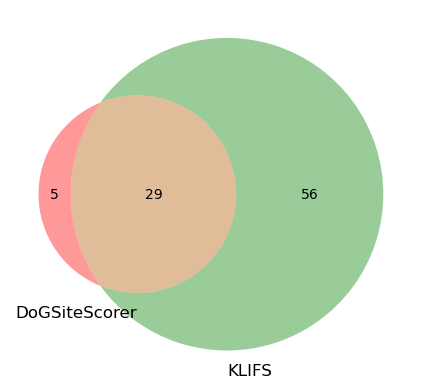

In [31]:
print(f"Residue overlap between the two methods using {best_pocket_id}.")
venn2(
    [set(dogsite_pocket_residues), set(klifs_pocket_residues)],
    set_labels=("DoGSiteScorer", "KLIFS"),
)
plt.show()

As we can see, the subpocket we choose from DoGSiteScorer is very precise. In fact, 29 out of the 34 residues do overlap with the KLIFS definition (85 residues).
Though, the KLIFS pocket covers a larger overall pocket area.
Out of interest, we can also do the same comparison using the pocket ``P_0`` (instead of subpocket ``P_0_0``) to see how that compares to KLIFS.

In [32]:
# Get info for largest DoGSiteScorer pocket P_0
new_pocket_id = "P_0"
dogsite_pocket_residues_df_p0 = get_pocket_residues(
    get_selected_pocket_location(job_location, new_pocket_id)
)
dogsite_pocket_residues_p0 = dogsite_pocket_residues_df_p0["residue_number"].to_list()
print(f"DoGSiteScorer pocket {new_pocket_id} with {len(dogsite_pocket_residues_p0)} detected.")
# NBVAL_CHECK_OUTPUT

DoGSiteScorer pocket P_0 with 35 detected.


Residue overlap between the two methods using P_0.


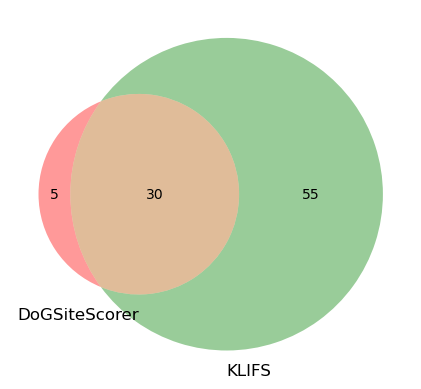

In [33]:
print(f"Residue overlap between the two methods using {new_pocket_id}.")
venn2(
    [set(dogsite_pocket_residues_p0), set(klifs_pocket_residues)],
    set_labels=("DoGSiteScorer", "KLIFS"),
)
plt.show()

## Discussion

We introduced the idea of binding site detection algorithms using DoGSiteScorer, which can be queried through the [proteins.plus](https://proteins.plus) server.
Besides investigating into the main (known) binding site, as exemplified above, one can use other predicted pockets to initiate drug design campaigns against a novel, e.g. allosteric or less explored, pocket.